In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install ultralytics -q

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# ✅ Fixed imports — label_binarize moved to sklearn.preprocessing
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score,
                             accuracy_score, f1_score, balanced_accuracy_score)

Class counts: [7970, 3140, 2103, 2079, 1257, 2055, 1847, 3323, 1677, 1702]


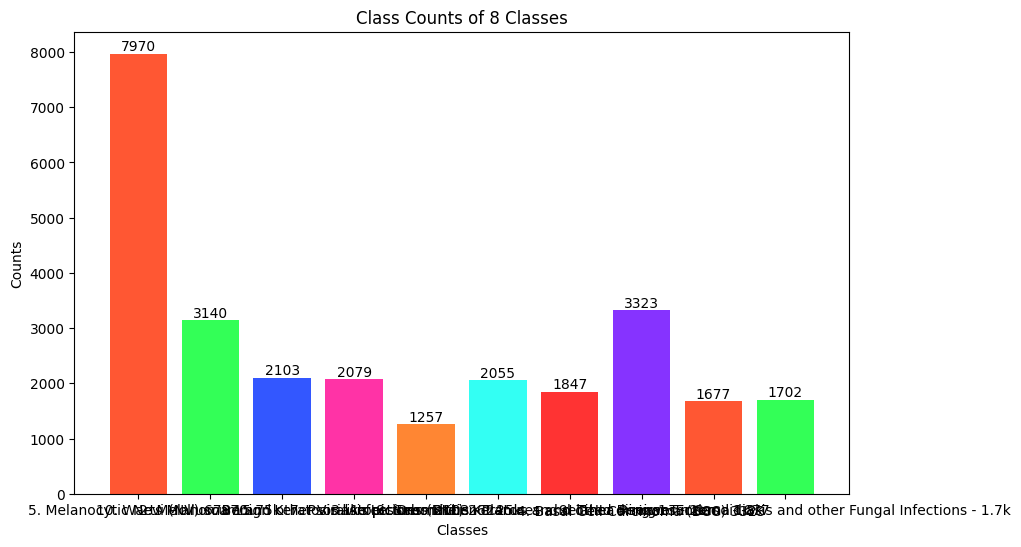

In [3]:
import os
import shutil
import matplotlib.pyplot as plt

data_path = '/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES'
output_path = '/kaggle/working/Skin-disease-images'

if os.path.exists(output_path):
    shutil.rmtree(output_path)

if not os.path.exists(output_path):
    shutil.copytree(data_path, output_path)

classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 8 Classes')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}', ha='center', va='bottom')
plt.show()

In [5]:
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def oversampler(class_name, class_count, target=7000, batch_size=32, target_size=(224, 224)):
    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    curr_dir = os.path.join(output_path, class_name)
    save_dir = curr_dir
    images = [os.path.join(curr_dir, img) for img in os.listdir(curr_dir)]
    cnt = class_count

    while cnt < target:
        batch_images = []
        for img_path in random.sample(images, batch_size):
            img = Image.open(img_path).resize(target_size)
            batch_images.append(np.array(img))
        batch_images = np.array(batch_images)
        for _ in datagen.flow(batch_images, batch_size=batch_size,
                              save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
            cnt += batch_size
            if cnt >= target:
                break
        print(f"Processed {cnt}/{target} images for {class_name}")

def undersampler(class_name, class_count, target_count=7000):
    curr_dir = os.path.join(output_path, class_name)
    images = os.listdir(curr_dir)
    images_to_delete = random.sample(images, class_count - target_count)
    for image in images_to_delete:
        try:
            os.remove(os.path.join(curr_dir, image))
        except Exception as e:
            print(f"Error deleting: {e}")
    print(f"Deleted {len(images_to_delete)} images for {class_name}")

Deleted 970 images for 5. Melanocytic Nevi (NV) - 7970
Processed 7012/7000 images for 2. Melanoma 15.75k
Processed 7031/7000 images for 10. Warts Molluscum and other Viral Infections - 2103
Processed 7007/7000 images for 6. Benign Keratosis-like Lesions (BKL) 2624
Processed 7017/7000 images for 3. Atopic Dermatitis - 1.25k
Processed 7015/7000 images for 7. Psoriasis pictures Lichen Planus and related diseases - 2k
Processed 7031/7000 images for 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Processed 7003/7000 images for 4. Basal Cell Carcinoma (BCC) 3323
Processed 7021/7000 images for 1. Eczema 1677
Processed 7014/7000 images for 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
Balancing completed.
Updated class counts: [7000, 6987, 6985, 6978, 6969, 6976, 7003, 6982, 6969, 6965]


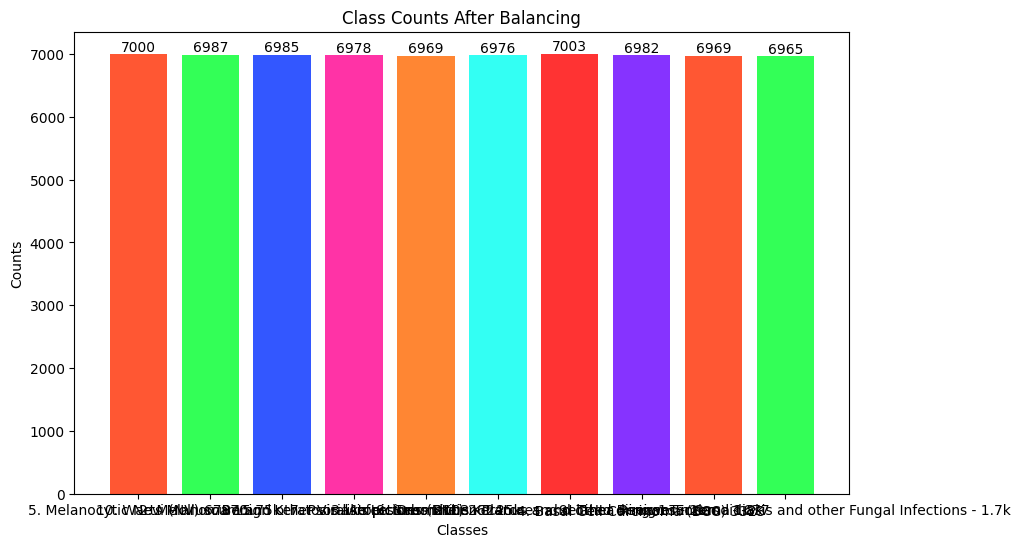

In [6]:
for i, class_name in enumerate(classes):
    if class_counts[i] < 7000:
        oversampler(class_name, class_counts[i])
    else:
        undersampler(class_name, class_counts[i])

print("Balancing completed.")

classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Updated class counts:", class_counts)

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts After Balancing')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height}', ha='center', va='bottom')
plt.show()

In [7]:
train_path = '/kaggle/working/train'
val_path   = '/kaggle/working/val'
test_path  = '/kaggle/working/test'

for p in [train_path, val_path, test_path]:
    os.makedirs(p, exist_ok=True)

train_ratio, val_ratio = 0.8, 0.10

for class_folder in os.listdir(output_path):
    class_path = os.path.join(output_path, class_folder)

    for split_path in [train_path, val_path, test_path]:
        os.makedirs(os.path.join(split_path, class_folder), exist_ok=True)

    images = os.listdir(class_path)
    random.shuffle(images)
    num_images = len(images)

    num_train = int(num_images * train_ratio)
    num_val   = int(num_images * val_ratio)

    splits = {
        train_path: images[:num_train],
        val_path:   images[num_train:num_train + num_val],
        test_path:  images[num_train + num_val:]
    }

    for split_path, split_images in splits.items():
        for image in split_images:
            shutil.copy(
                os.path.join(class_path, image),
                os.path.join(split_path, class_folder, image)
            )

print("Dataset split completed.")

Dataset split completed.


In [8]:
import yaml

classes = sorted(os.listdir(train_path))
num_classes = len(classes)

data_yaml = {
    'path': '/kaggle/working',
    'train': 'train',
    'val': 'val',
    'test': 'test',
    'nc': num_classes,
    'names': classes
}

yaml_path = '/kaggle/working/skin_disease.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("YAML config created:")
print(open(yaml_path).read())

YAML config created:
names:
- 1. Eczema 1677
- 10. Warts Molluscum and other Viral Infections - 2103
- 2. Melanoma 15.75k
- 3. Atopic Dermatitis - 1.25k
- 4. Basal Cell Carcinoma (BCC) 3323
- 5. Melanocytic Nevi (NV) - 7970
- 6. Benign Keratosis-like Lesions (BKL) 2624
- 7. Psoriasis pictures Lichen Planus and related diseases - 2k
- 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
- 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
nc: 10
path: /kaggle/working
test: test
train: train
val: val



In [9]:
from ultralytics import YOLO

# Load pretrained YOLOv8 classification model
model = YOLO('yolov8m-cls.pt')  # Options: yolov8n-cls, yolov8s-cls, yolov8m-cls, yolov8l-cls

# Train
results = model.train(
    data='/kaggle/working',   # Folder with train/val/test subfolders
    epochs=50,
    imgsz=224,
    batch=32,
    patience=5,               # Early stopping
    lr0=0.0001,               # Initial learning rate
    optimizer='Adam',
    save=True,
    project='/kaggle/working/yolov8_runs',
    name='skin_disease',
    verbose=True
)

print("Training completed!")

Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=skin_disease, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=5, perspective=0.

In [10]:
# Load best trained model
best_model = YOLO('/kaggle/working/yolov8_runs/skin_disease/weights/best.pt')

# Official YOLO validation
val_results = best_model.val(
    data='/kaggle/working',
    imgsz=224,
    batch=32,
    split='test'
)

print(val_results)

Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,775,466 parameters, 0 gradients, 41.6 GFLOPs
train: /kaggle/working/train... found 55848 images in 10 classes ✅ 
val: /kaggle/working/val... found 6976 images in 10 classes ✅ 
test: /kaggle/working/test... found 6990 images in 10 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 597.2±208.0 MB/s, size: 23.8 KB)
test: Scanning /kaggle/working/test... 6990 images, 0 corrupt: 100% ━━━━━━━━━━━━ 6990/6990 2.7Kit/s 2.6s0.1s
test: New cache created: /kaggle/working/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 219/219 11.1it/s 19.7s<0.1s
                   all      0.954      0.999
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.Confus

In [11]:
import torch
from pathlib import Path

y_true, y_pred, y_prob = [], [], []
class_names = sorted(os.listdir(test_path))

for class_idx, class_name in enumerate(class_names):
    class_folder = os.path.join(test_path, class_name)
    image_files  = [os.path.join(class_folder, f) for f in os.listdir(class_folder)]

    for img_path in image_files:
        result = best_model.predict(img_path, imgsz=224, verbose=False)[0]
        probs  = result.probs.data.cpu().numpy()  # Softmax probabilities
        pred   = int(np.argmax(probs))

        y_true.append(class_idx)
        y_pred.append(pred)
        y_prob.append(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print(f"Total test samples: {len(y_true)}")

Total test samples: 6990


Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.93      0.95      0.94       698
           10. Warts Molluscum and other Viral Infections - 2103       0.94      0.93      0.94       699
                                              2. Melanoma 15.75k       0.99      1.00      0.99       700
                                    3. Atopic Dermatitis - 1.25k       0.94      0.93      0.93       698
                              4. Basal Cell Carcinoma (BCC) 3323       0.98      0.97      0.98       699
                                 5. Melanocytic Nevi (NV) - 7970       0.99      0.97      0.98       700
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.96      0.97      0.97       699
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.94      0.91      0.92       699
          8. Seborrhe

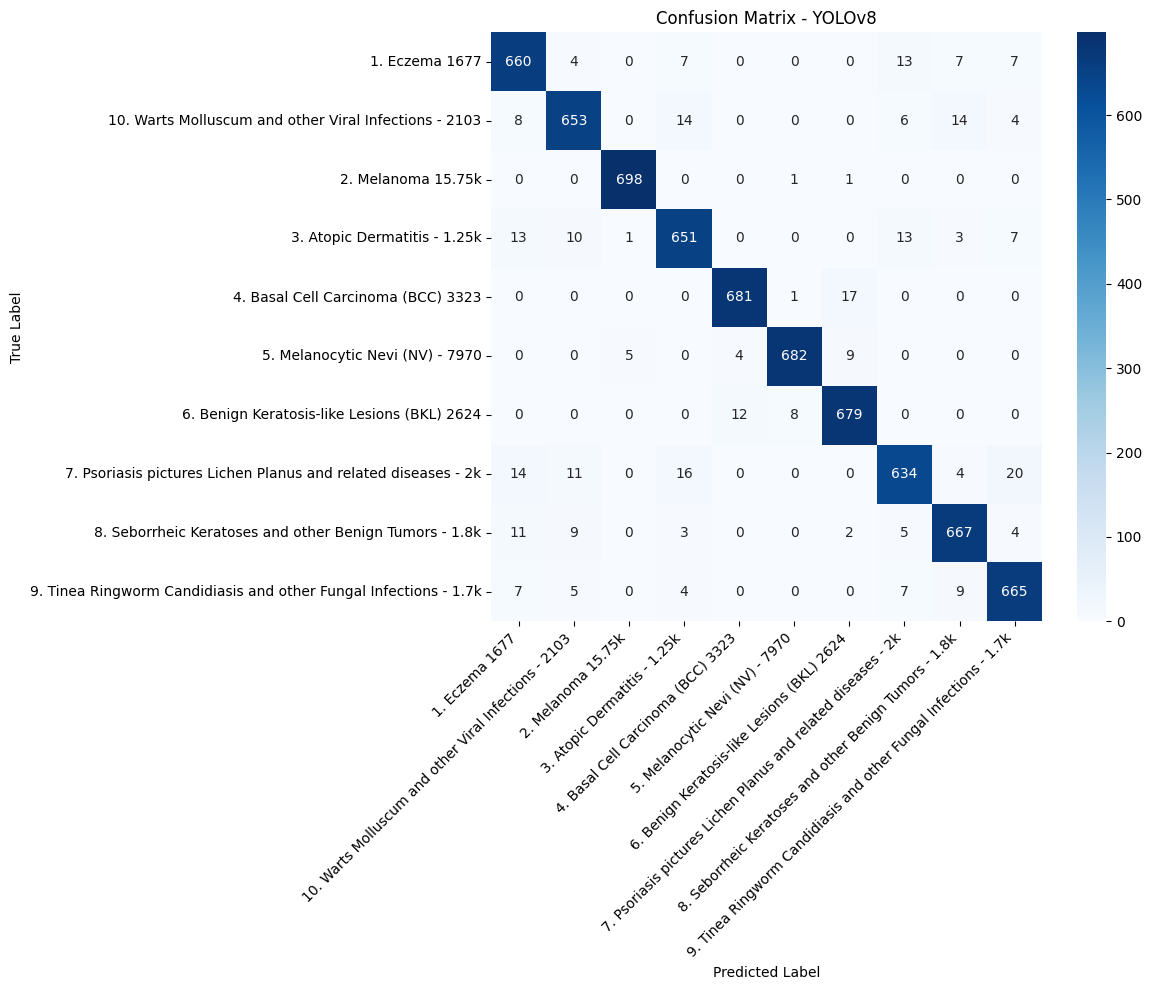

In [12]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLOv8")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

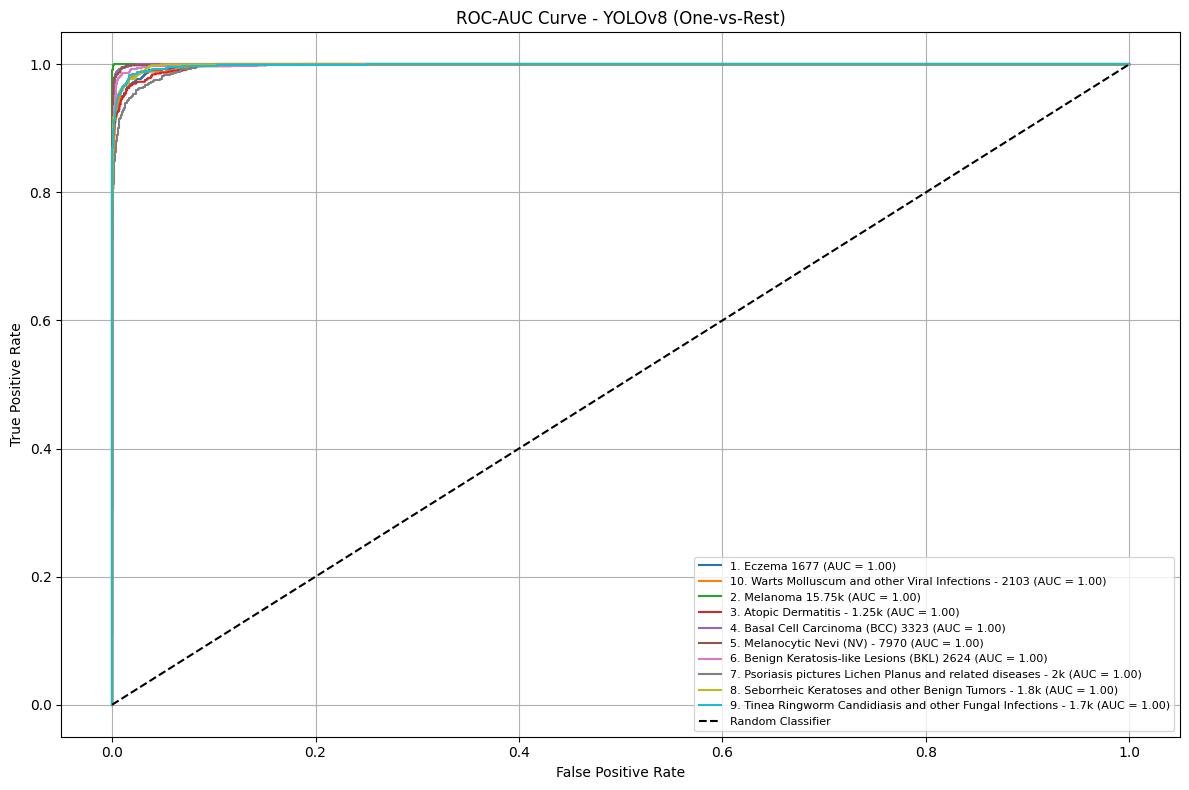


Mean AUC Score: 0.9986


In [13]:
n_classes   = len(class_names)
y_true_bin  = label_binarize(y_true, classes=list(range(n_classes)))

plt.figure(figsize=(12, 8))
auc_scores = []

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - YOLOv8 (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean AUC Score: {np.mean(auc_scores):.4f}")

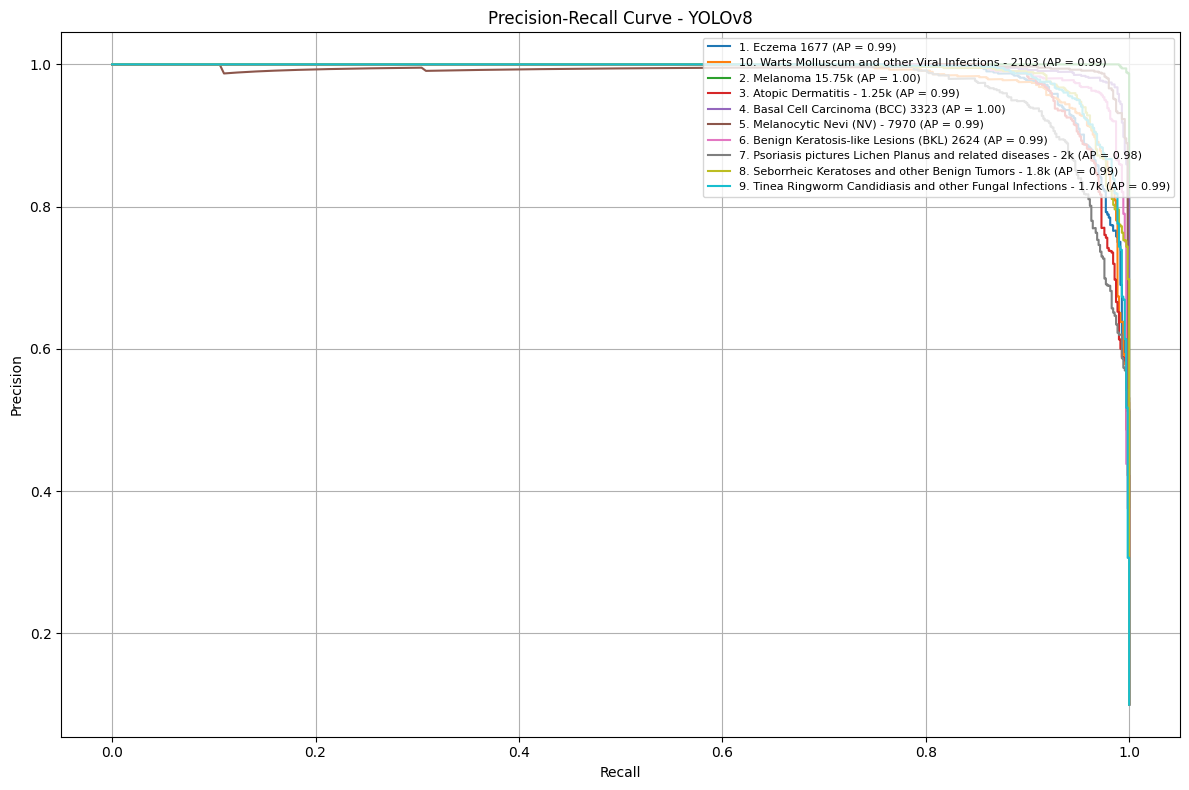


Mean Average Precision (mAP): 0.9899


In [14]:
plt.figure(figsize=(12, 8))
ap_scores = []

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    ap_scores.append(ap)
    plt.plot(recall, precision, label=f'{class_names[i]} (AP = {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - YOLOv8')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean Average Precision (mAP): {np.mean(ap_scores):.4f}")

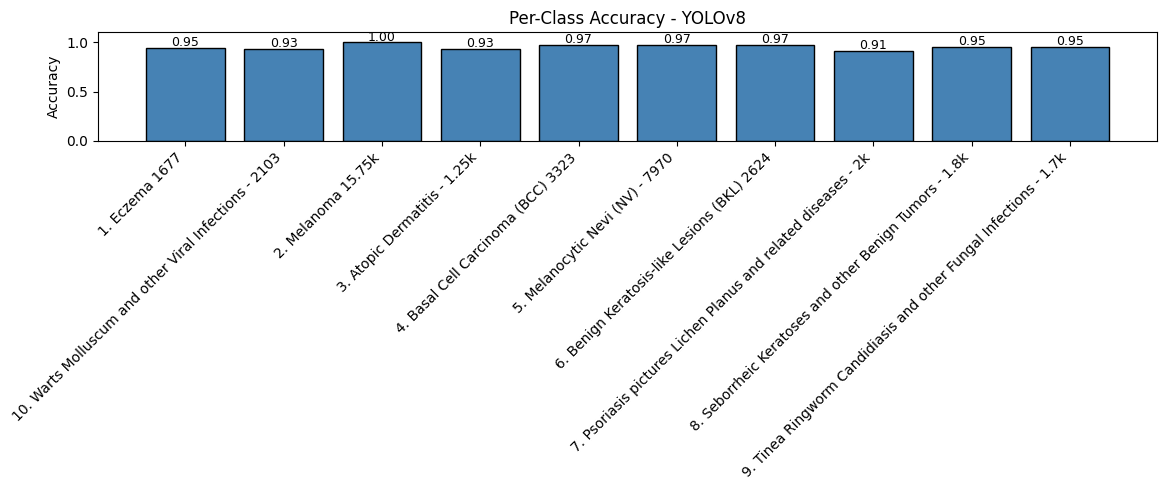


===== Overall Metrics Summary - YOLOv8 =====
Accuracy:              0.9542
Balanced Accuracy:     0.9542
Macro F1-Score:        0.9542
Weighted F1-Score:     0.9542
Mean AUC:              0.9986
Mean Avg Precision:    0.9899


In [15]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy - YOLOv8')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== Overall Metrics Summary - YOLOv8 =====")
print(f"Accuracy:              {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:     {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1-Score:        {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score:     {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Mean AUC:              {np.mean(auc_scores):.4f}")
print(f"Mean Avg Precision:    {np.mean(ap_scores):.4f}")